# Dichromatic Polynomial of a Digraph

Implementation of the recursive formula from **Theorem 2** of:

> González-Moreno et al., *The Dichromatic Polynomial of a Digraph*,  
> Graphs and Combinatorics 38 (2022), article 85.

Input format: Collapse section CODE (click on the little arrow to the left of it) and go to section "TO USE" to view the 3 different input formats.

---
**Run all cells top to bottom before using anything.**


# CODE

## Cell 1 — Imports

In [ ]:
from sympy import symbols, Poly
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np

k = symbols('k')
print("✓ imports ok")


✓ imports ok


## Cell 2 — digraph6 Codec

In [ ]:
def _n_from_bytes(data, pos):
    if data[pos] != 126:
        return data[pos] - 63, pos + 1
    pos += 1
    if data[pos] != 126:
        x = 0
        for _ in range(3):
            x = (x << 6) | (data[pos] - 63); pos += 1
        return x, pos
    pos += 1
    x = 0
    for _ in range(6):
        x = (x << 6) | (data[pos] - 63); pos += 1
    return x, pos

def parse_d6(s):
    """digraph6 string → n×n adjacency matrix."""
    s = s.strip()
    if s.startswith(">>digraph6<<"): s = s[len(">>digraph6<<"):]
    if s.startswith("&"): s = s[1:]
    data = s.encode("ascii")
    n, pos = _n_from_bytes(data, 0)
    bits = []
    for byte in data[pos:]:
        v = byte - 63
        for shift in range(5, -1, -1):
            bits.append((v >> shift) & 1)
    adj = [[0]*n for _ in range(n)]
    idx = 0
    for i in range(n):
        for j in range(n):
            if idx < len(bits):
                adj[i][j] = bits[idx]; idx += 1
    return adj

def to_d6(adj):
    """n×n adjacency matrix → digraph6 string."""
    n = len(adj)
    if n <= 62:
        n_bytes = bytes([n + 63])
    elif n <= 258047:
        x = n; b = []
        for _ in range(3): b.append((x & 0x3F) + 63); x >>= 6
        n_bytes = bytes([126]) + bytes(reversed(b))
    else:
        x = n; b = []
        for _ in range(6): b.append((x & 0x3F) + 63); x >>= 6
        n_bytes = bytes([126, 126]) + bytes(reversed(b))
    bits = [adj[i][j] for i in range(n) for j in range(n)]
    while len(bits) % 6: bits.append(0)
    r_bytes = []
    for i in range(0, len(bits), 6):
        v = 0
        for b in bits[i:i+6]: v = (v << 1) | b
        r_bytes.append(v + 63)
    return "&" + (n_bytes + bytes(r_bytes)).decode("ascii")

print("✓ digraph6 codec ok")


✓ digraph6 codec ok


## Cell 3 — Graph Utilities

In [ ]:
def _n(adj): return len(adj)
def _adj_copy(adj): return [row[:] for row in adj]

def _is_acyclic(adj):
    """DFS cycle detection. Returns True if no directed cycle."""
    n = _n(adj)
    WHITE, GRAY, BLACK = 0, 1, 2
    color = [WHITE] * n
    def dfs(u):
        color[u] = GRAY
        for v in range(n):
            if adj[u][v]:
                if color[v] == GRAY: return True
                if color[v] == WHITE and dfs(v): return True
        color[u] = BLACK
        return False
    return not any(dfs(u) for u in range(n) if color[u] == 0)

def _strong_components(adj):
    """Kosaraju's algorithm → list of frozensets."""
    n = _n(adj)
    visited = [False]*n; order = []
    def dfs1(u):
        stack = [(u, 0)]
        while stack:
            v, idx = stack[-1]
            if idx == 0: visited[v] = True
            found = False
            for w in range(idx, n):
                stack[-1] = (v, w+1)
                if adj[v][w] and not visited[w]:
                    visited[w] = True; stack.append((w, 0)); found = True; break
            if not found: stack.pop(); order.append(v)
    for u in range(n):
        if not visited[u]: dfs1(u)
    T = [[adj[j][i] for j in range(n)] for i in range(n)]
    visited2 = [False]*n; comps = []
    def dfs2(u):
        comp = []; stack = [u]; visited2[u] = True
        while stack:
            v = stack.pop(); comp.append(v)
            for w in range(n):
                if T[v][w] and not visited2[w]:
                    visited2[w] = True; stack.append(w)
        return comp
    for u in reversed(order):
        if not visited2[u]: comps.append(frozenset(dfs2(u)))
    return comps

print("✓ graph utilities ok")


✓ graph utilities ok


## Cell 4 — Digraph Operations

In [ ]:
def _add_arc(adj, u, v):
    a = _adj_copy(adj); a[u][v] = 1; return a

def _contract(adj, vertex_set):
    """Contract a set of vertices into one (no loops, no parallel arcs)."""
    n = _n(adj); S = set(vertex_set)
    others = sorted(set(range(n)) - S)
    new_order = [min(S)] + others
    m = 1 + len(others)
    new_adj = [[0]*m for _ in range(m)]
    for i, u in enumerate(new_order):
        for j, v in enumerate(new_order):
            if i == j: continue
            u_group = S if i == 0 else {u}
            v_group = S if j == 0 else {v}
            new_adj[i][j] = 1 if any(adj[a][b] for a in u_group for b in v_group) else 0
    return new_adj

def _find_non_symmetric_pair(adj):
    """Find (u,v) where NOT both u->v and v->u. Returns None if fully symmetric."""
    n = _n(adj)
    for u in range(n):
        for v in range(u+1, n):
            if not (adj[u][v] and adj[v][u]): return u, v
    return None

def _paths_of_length_ge2(adj, u, v):
    """Simple (u,v)-paths of length >= 2 whose induced subdigraph is acyclic."""
    n = _n(adj); results = []
    def dfs(current, path, visited):
        for nxt in range(n):
            if not adj[current][nxt]: continue
            if nxt == v and len(path) >= 2:
                full = path + [v]
                induced = [[adj[a][b] for b in full] for a in full]
                if _is_acyclic(induced): results.append(tuple(full))
            elif nxt != v and nxt not in visited:
                visited.add(nxt); dfs(nxt, path+[nxt], visited); visited.remove(nxt)
    dfs(u, [u], {u})
    return results

def _build_equivalence_classes(paths, u, v):
    """
    Equivalence classes of Huv under relation (3) of the paper:
    H_i ~ H_j iff union V(T) for T in H_i = union V(T) for T in H_j.
    Returns list of distinct R*_i vertex-sets (frozensets).
    """
    if not paths: return []
    m = len(paths)
    seen = {}
    for r in range(1, m+1):
        for combo in combinations(range(m), r):
            vset = frozenset(vtx for idx in combo for vtx in paths[idx])
            if vset not in seen: seen[vset] = combo
    return list(seen.keys())

print("✓ digraph operations ok")


✓ digraph operations ok


## Cell 5 — Dichromatic Polynomial (Theorem 2)

$$P(D,k) = P(D + \{uv,vu\},\,k) + P(D/\{u,v\},\,k) + \sum_{i=1}^{\ell} P(D/R_i^*,\,k)$$

**Bug fix included:** R\*ᵢ terms where the induced subgraph has a cycle contribute 0
(coloring all those vertices the same would create a monochromatic cycle → invalid).


In [ ]:
def _poly_complete_symmetric(n):
    """P(complete symmetric digraph) = k(k-1)···(k-n+1)."""
    result = Poly(1, k, domain='ZZ')
    for i in range(n): result = result * Poly(k - i, k, domain='ZZ')
    return result

def _rec(adj):
    n = _n(adj)
    if n <= 1:                    return Poly(k**n, k, domain='ZZ')
    if _is_acyclic(adj):          return Poly(k**n, k, domain='ZZ')

    # Decompose by strong components (Theorem 5)
    comps = _strong_components(adj)
    if len(comps) > 1:
        result = Poly(1, k, domain='ZZ')
        for comp in comps:
            comp = sorted(comp)
            sub = [[adj[u][v] for v in comp] for u in comp]
            result = result * _rec(sub)
        return result

    pair = _find_non_symmetric_pair(adj)
    if pair is None: return _poly_complete_symmetric(n)  # fully symmetric

    u, v = pair

    # Term 1: make (u,v) symmetric
    p1 = _rec(_add_arc(_add_arc(adj, u, v), v, u))

    # Term 2: contract {u,v}
    p2 = _rec(_contract(adj, {u, v}))

    # Terms 3+: one per equivalence class R*_i
    all_paths = _paths_of_length_ge2(adj, u, v) + _paths_of_length_ge2(adj, v, u)
    R_stars   = _build_equivalence_classes(all_paths, u, v)

    p3 = Poly(0, k, domain='ZZ')
    for R_star in R_stars:
        # Skip if induced subgraph on R*_i has a cycle:
        # coloring all those vertices the same would create a monochromatic cycle.
        R_list  = sorted(R_star)
        induced = [[adj[a][b] for b in R_list] for a in R_list]
        if not _is_acyclic(induced):
            continue
        p3 = p3 + _rec(_contract(adj, R_star))

    return p1 + p2 + p3

def dichromatic_poly(adj):
    """Return P(D, k) as a sympy Poly."""
    return _rec(adj)

def dichromatic_number(adj):
    """Return dc(D) = min{ k ∈ ℤ⁺ : P(D,k) > 0 }."""
    if _is_acyclic(adj): return 1
    poly = dichromatic_poly(adj)
    for kv in range(1, _n(adj) + 2):
        if poly.eval(kv) > 0: return kv
    return _n(adj)

print("✓ dichromatic_poly and dichromatic_number ok")


✓ dichromatic_poly and dichromatic_number ok


## Cell 6 — I/O Helpers

In [ ]:
def process_d6_string(s):
    """Parse one digraph6 string and print polynomial + dichromatic number."""
    s = s.strip()
    if not s or s.startswith("#"): return
    adj  = parse_d6(s)
    poly = dichromatic_poly(adj)
    dc   = dichromatic_number(adj)
    print(f"d6     : {s}")
    print(f"n      : {_n(adj)}")
    print(f"P(D,k) : {poly.as_expr()}")
    print(f"dc(D)  : {dc}")
    print()

def process_d6_file(path):
    """Process every graph in a .d6 file."""
    with open(path) as fh:
        for line in fh:
            process_d6_string(line)

print("✓ I/O helpers ok")


✓ I/O helpers ok


## Cell 6b — Tournament Format (McKay upper-triangle)

In [ ]:
import math

def _n_from_tri_len(L):
    """Infer n from upper-triangle bit string of length L = n*(n-1)/2."""
    n = int((1 + math.sqrt(1 + 8*L)) / 2)
    assert n*(n-1)//2 == L, f"String length {L} is not a valid upper-triangle length"
    return n

def parse_tournament(s):
    s = s.strip()
    n = _n_from_tri_len(len(s))
    adj = [[0]*n for _ in range(n)]
    idx = 0

    for i in range(n):
        for j in range(i+1, n):
            if s[idx] == '1':
                adj[i][j] = 1
            else:
                adj[j][i] = 1
            idx += 1

    return adj

def process_tournament_string(s):
    """Parse one tournament string and print polynomial + dichromatic number."""
    s = s.strip()
    if not s or s.startswith("#"): return
    adj  = parse_tournament(s)
    poly = dichromatic_poly(adj)
    dc   = dichromatic_number(adj)
    print(f"tournament : {s}")
    print(f"  n      = {_n(adj)}")
    print(f"  P(D,k) = {poly.as_expr()}")
    print(f"  dc(D)  = {dc}")
    print()

def process_tournament_file(path):
    """Process every tournament in a file (one upper-triangle string per line)."""
    with open(path) as fh:
        for line in fh:
            process_tournament_string(line)

print("✓ tournament format loaded")


✓ tournament format loaded


In [ ]:
# ── Process a whole tournament file ──────────────────────────────────────────
# Uncomment and point to your file:
# process_tournament_file("tournaments5.txt") # change name to local file

## Graph printing

In [ ]:
def print_graph(adj, labels=None):
    """Print a text representation of the digraph."""
    n = len(adj)
    if labels is None:
        labels = [str(i) for i in range(n)]
    print("Digraph:")
    for i in range(n):
        arcs = [labels[j] for j in range(n) if adj[i][j]]
        if arcs:
            print(f"  {labels[i]} → {', '.join(arcs)}")
        else:
            print(f"  {labels[i]} → (none)")

def draw_graph(adj, labels=None, title="Digraph"):
    """Draw the digraph with a circular layout."""
    n = len(adj)
    if labels is None:
        labels = [str(i) for i in range(n)]

    angles = [2 * np.pi * i / n for i in range(n)]
    pos = {i: (np.cos(a), np.sin(a)) for i, a in enumerate(angles)}

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13)

    for i in range(n):
        for j in range(n):
            if not adj[i][j]: continue
            xi, yi = pos[i]
            xj, yj = pos[j]
            if adj[j][i]:  # offset symmetric arcs
                dx, dy = yj - yi, -(xj - xi)
                norm = np.sqrt(dx**2 + dy**2) + 1e-9
                off = 0.08
                xi2 = xi + off*dx/norm; yi2 = yi + off*dy/norm
                xj2 = xj + off*dx/norm; yj2 = yj + off*dy/norm
            else:
                xi2, yi2, xj2, yj2 = xi, yi, xj, yj
            ax.annotate("",
                xy=(xj2, yj2), xytext=(xi2, yi2),
                arrowprops=dict(arrowstyle="-|>", color="steelblue",
                                lw=1.5, mutation_scale=15,
                                shrinkA=14, shrinkB=14))

    for i in range(n):
        x, y = pos[i]
        ax.add_patch(plt.Circle((x, y), 0.1, color='steelblue', zorder=3))
        ax.text(x, y, labels[i], ha='center', va='center',
                color='white', fontsize=11, fontweight='bold', zorder=4)

    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    plt.tight_layout()
    plt.show()

---
## Cell 7 — TEST CASES

Edit and re-run any of the cells below.


In [ ]:
# 4-cycle 0->1->2->3->0 plus arcs 0->4
# In the paper: Proof 8, case 2b, P(C*,k): P(D,k) = k^5 - k^2
adj = [
    [0, 1, 0, 0, 1],   # 0 -> 1, 4
    [0, 0, 1, 0, 0],   # 1 -> 2
    [0, 0, 0, 1, 0],   # 2 -> 3
    [1, 0, 0, 0, 0],   # 3 -> 0
    [0, 0, 0, 0, 0],   # 4 -> 2
]
print("d6    :", to_d6(adj))
print("P(D,k):", dichromatic_poly(adj).as_expr())
print("dc(D) :", dichromatic_number(adj))


d6    : &DQOS??
P(D,k): k**5 - k**2
dc(D) : 2


In [ ]:
# 4-cycle 0->1->2->3->0 plus arcs 0->4 and 4->2
# In the paper: Proof 8, case 2b, P(C**,k): P(D,k) = k^5 - 2k^2 + k
adj = [
    [0, 1, 0, 0, 1],   # 0 -> 1, 4
    [0, 0, 1, 0, 0],   # 1 -> 2
    [0, 0, 0, 1, 0],   # 2 -> 3
    [1, 0, 0, 0, 0],   # 3 -> 0
    [0, 0, 1, 0, 0],   # 4 -> 2
]
print("d6    :", to_d6(adj))
print("P(D,k):", dichromatic_poly(adj).as_expr())
print("dc(D) :", dichromatic_number(adj))


d6    : &DQOSA?
P(D,k): k**5 - 2*k**2 + k
dc(D) : 2


In [ ]:
# 4 - cycle 1->2->3->4 and 3-cycle 1->2->0->1
# see Proof 8, case 3 (before a); I believe that there is a typo in the book, see handwritten notes; should be k^5 - k^3 - k^2 +k
adj_c4_c3 = [
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [0, 1, 0, 0, 0]
    ]
print("D")
print("P(D,k):", dichromatic_poly(adj_c4_c3).as_expr())
print("dc(D) :", dichromatic_number(adj_c4_c3))


D
P(D,k): k**5 - k**3 - k**2 + k
dc(D) : 2


In [ ]:
# Same as above with the added edge 0->3; should yield same polynomial
adj_c4_c3 = [
    [0, 1, 0, 0, 1],
    [0, 0, 1, 0, 0],
    [1, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [0, 1, 0, 0, 0]
    ]
print("D")
print("P(D,k):", dichromatic_poly(adj_c4_c3).as_expr())
print("dc(D) :", dichromatic_number(adj_c4_c3))


D
P(D,k): k**5 - k**3 - k**2 + k
dc(D) : 2


In [ ]:
# STILL WORKING ON THIS
adj_c4_c3 = [
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0],
    [1, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [1, 1, 0, 0, 0]
    ]
print("D")
print("P(D,k):", dichromatic_poly(adj_c4_c3).as_expr())
print("dc(D) :", dichromatic_number(adj_c4_c3))


D
P(D,k): k**5 - 2*k**3 - k**2 + 2*k
dc(D) : 2


In [ ]:
# ── D: process a whole .d6 file ──────────────────────────────────────────────
# Uncomment and point to your file:
# process_d6_file("digraphs4.d6")

Digraph:
  0 → 1
  1 → 2
  2 → 0
P(D,k) = k**3 - k,  dc = 2


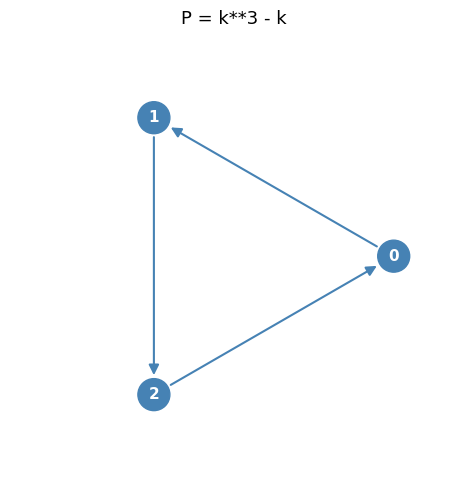

In [ ]:
adj = [[0,1,0],[0,0,1],[1,0,0]]   # C3

print_graph(adj)
print(f"P(D,k) = {dichromatic_poly(adj).as_expr()},  dc = {dichromatic_number(adj)}")
draw_graph(adj, title=f"P = {dichromatic_poly(adj).as_expr()}")

# TO USE: Obtaining Dichromatic Polynomial

### Option 1:
You can pass the input in matrix form. Enter a matrix for your graph; entries are binary numbers. Entry M[ij] = 1 means that there exists a vertex from i to j. M[ij] = 0 means that there does not exist a vertex from i to j. E.g. C3 would have a matrix of
$\begin{bmatrix} 0 & 1 & 0 \\
0 & 0 & 1 \\
1 & 0 & 0 \end{bmatrix}$
corresponding to the edges $0 \to 1, 1 \to 2, 2 \to 0$.

D
P(D,k): k**5 - k**3 - k**2 + k
dc(D) : 2
Digraph:
  0 → 1, 3, 4
  1 → 2
  2 → 0, 3
  3 → 4
  4 → 1


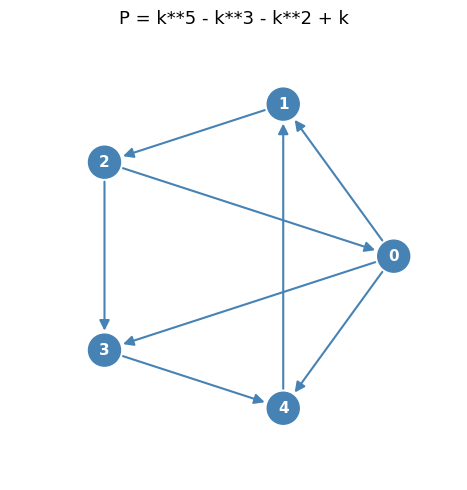

In [ ]:
# for processing & calculating dichromatic number & polynomial
edge_matrix = [
    [0, 1, 0, 1, 1],
    [0, 0, 1, 0, 0],
    [1, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [0, 1, 0, 0, 0]
    ]
print("D")
print("P(D,k):", dichromatic_poly(edge_matrix).as_expr())
print("dc(D) :", dichromatic_number(edge_matrix))

# for printing
print_graph(edge_matrix)
draw_graph(edge_matrix, title=f"P = {dichromatic_poly(edge_matrix).as_expr()}")

### Option 2:
You can pass the input in digraph6 form from https://users.cecs.anu.edu.au/~bdm/data/digraphs.html. This includes sections
- Digraphs
- Oriented graphs
- Eulerian graphs
- Vertex-transitive tournaments and
- Non-reconstructable digraphs
(all with or without loops).

d6     : &B[O
n      : 3
P(D,k) : k**3 - k**2
dc(D)  : 2

Digraph:
  0 → 2, 4
  1 → 3
  2 → 0, 5
  3 → 1
  4 → 2, 5
  5 → 0, 4


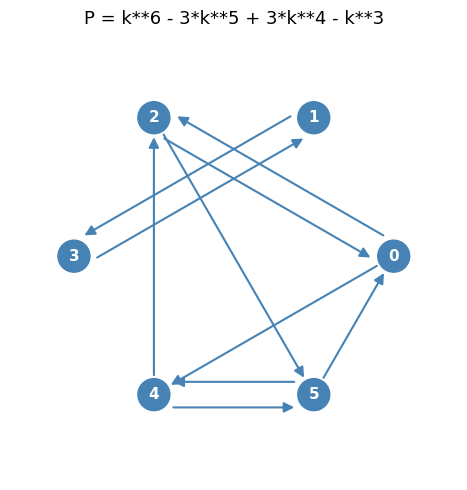

In [ ]:
# for processing the string & calculating dichromatic number & polynomial
process_d6_string("&B[O")

# for printing the graph
mat = parse_d6("&EIC`OHa")
print_graph(mat)
draw_graph(mat, title=f"P = {dichromatic_poly(mat).as_expr()}")

### Option 3:
You can pass the input in upper triangle form of the adjacency matrix in row order form from https://users.cecs.anu.edu.au/~bdm/data/digraphs.html. This includes sections
- Tournaments
- Self-converse-Tournaments
- Regular and Semi-regular Tournaments
- Locally-transitive Tournaments
- Acyclic Digraphs.


Uncomment and run the cell below to use this input format. You can read more about the encoding in the matrices in the above link.

D
P(D,k): k**9 - 28*k**7 + 72*k**6 + 35*k**5 - 338*k**4 + 433*k**3 - 177*k**2 + 2*k
dc(D) : 2
Digraph:
  0 → 2, 3, 7
  1 → 0, 4, 5
  2 → 1, 3, 4, 7
  3 → 1, 4, 5, 8
  4 → 0, 5, 6, 8
  5 → 0, 2, 6, 8
  6 → 0, 1, 2, 3
  7 → 1, 3, 4, 5, 6
  8 → 0, 1, 2, 6, 7


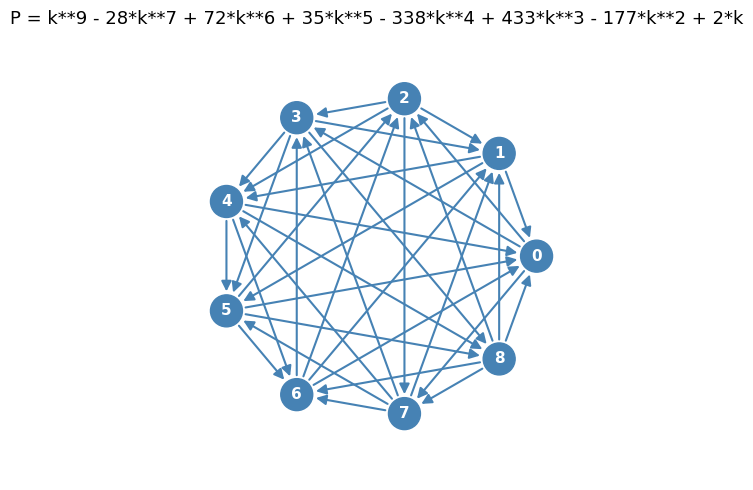

In [ ]:
# for processing the string & calculating dichromatic number & polynomial
upper_triang = parse_tournament('011000100011000110010110011101101000')
print("D")
print("P(D,k):", dichromatic_poly(upper_triang).as_expr())
print("dc(D) :", dichromatic_number(upper_triang))

# for printing
print_graph(upper_triang)
draw_graph(upper_triang, title=f"P = {dichromatic_poly(upper_triang).as_expr()}")

# Non-isomorphic tournaments with same $A, W_A$

In [ ]:
# non-isomorphic tournament pairs/ tripes I have found so far up to n = 9
cospectral_groups_to_n9 =  [['000100000000010001000001000110100111', '000100000000010001000001001010110011'],
                            ['000100000100000100100011100001010101', '001000000010000100100110100101010101'],
                            ['000101001001000001010100000110001101', '000101001010000001010010001010101101', '000101001010000001010010001100011101'],
                            ['000110001000010001001100000110010001', '010000100011000001010100000101001000'],
                            ['000110001000010001001100001010110001', '010000100011000001010100001001101000'],
                            ['000110001010000000011010001100110101', '010000101001000011100100000011001000'],
                            ['000110001010000000110000101010001001', '010000101010000111000110001110101101'],
                            ['000110001010000100100100101110100010', '001100001010000001100110001110110010'],
                            ['000110001100000100011011010100010101', '000110001100000100101010110010100101', '000110001100000100101010110100010101'],
                            ['000110101100000100110101011001001000', '010010100110000110010101011101001000'],
                            ['000111000101000100000101100110001010', '001110000001100100000110100110101010', '001110000101000000100011100010101010'],
                            ['001000001000000011000001001000110010', '010000000100000101000101001000110010'],
                            ['001001000010100001000000101000010101', '100001001100100101000100101000010101'],
                            ['001010001000010000101100101000001000', '010000100101000100001111001000101100'],
                            ['001010101010000011100100101101101101', '001010101010000101100101101001101101'],
                            ['001100000000110001000010010001110101', '100010001100100110000100110011100101'],
                            ['001100101001000100110110011001101000', '011000100011000110010110011101101000'],
                            ['001101000001010100000101101100001010', '001110000000110100000101101100001010', '001110000100010000100011101000101010'],
                            ['001110001000010001110001100001001001', '011010000010010100110101101001001001'],
                            ['001110001000010001110101000101001010', '001110001000010010110101001101001010', '011010000010010010110011001001101010', '011010000010010101010111000101101010', '011010000010010110010111001101101010'],
                            ['001110001000010100110101101001001001', '011010000010010100110011100001001001'],
                            ['001110001000010101010111000101101010', '011100001000010111100111001101011010'],
                            ['010000000101000011100101001001011100', '010000000101000101100111000001011100'],
                            ['010000100010100001100100001001001100', '100001001011000001001100000110010101'],
                            ['010001011001000101010000110000100101', '010001101001000101001000110000100101'],
                            ['010010000001010100100110000100110010', '100010001101000000110110000100110010'],
                            ['010100101100000111001011100101100010', '011000101010000111001101101101100010'],
                            ['010110001100000101110110010110101101', '011010001010000011110010010110101101'],
                            ['011000001000100110010110000001000000', '110000001101000110010101000001000000'],
                            ['011010000100010010100110101100110011', '101100001100010001100110101100110011'],
                            ['011100000011000100100101101110001010', '101100001011000100100101101110001010', '101100001101000010100101101110001010'],
                            ['100000001100010001001101001000110101', '100000001101000000011101001000110101'],
                            ['100010001100010010001101000110100111', '100010001100010010100100010011100101'],
                            ['100010001100100110001011010010010101', '100010001100100110010011010001010010'],
                            ['100011000111010010100010100110101111', '100011000111010100100110100110101111', '100011000111010101000101100110101111'],
                            ['100011001001001100001001100000100110', '100011001100001001001001100000100110'],
                            ['100011001100010101000100010010100000', '110000100101100110000100011100010000'],
                            ['100100001001010001001100000110001000', '100100001001010010001010001010101000', '100100001010010001001010001010101000'],
                            ['101000000011000000010000011000101000', '101000001000001101000110000010110001'],
                            ['101000001001000010000101101011101101', '101000001010000001000101101101011101'],
                            ['101001001001001010010010100001100101', '101001001001010010001100011010100101', '101001001010001001010010010010100101', '101001001010001001010011000010001101'],
                            ['101001001001001010010011000010001101', '101001001001001010010101001010001101', '101001001010010001001011000010001101'],
                            ['101001001001001010010100101001100101', '101001001001010010001011000010001101', '101001001001010010001101001010001101', '101001001010001001010100011010100101', '101001001010001001010101001010001101', '101001001010010001001010100001100101'],
                            ['101001001011000010010000011100010101', '110001000111000010010000011100010101'],
                            ['101100001011000101000100011010100101', '101100001101000011000100101001100101'],
                            ['110000000011000000110000101000001000', '110000001000010111000110001100101100'],
                            ['110000000101110110100101101100010111', '110000000110110101100011100100010111', '110000000110110101100101101100010111'],
                            ['111100001010011110011011011110100010', '111100001110100101011101110111000101'],
                            ['111100001010101110011010111110001000', '111100001010101110110010111011001000'],
                            ['111100001010110110101100111111000101', '111100001110010101101110110111100101']]

### counting k-cycles

In [ ]:
"""
Count and enumerate directed k-cycles in a directed graph given its adjacency matrix.

A directed k-cycle is a sequence of k DISTINCT vertices v0 -> v1 -> ... -> v(k-1) -> v0
following directed edges. Each cycle is counted once: rotations of the same cycle
(e.g. (0,1,2) and (1,2,0) and (2,0,1)) are the same cycle, so we canonicalize by
always starting the walk at its smallest-index vertex.

Note: a directed cycle and its reverse (e.g. 0->1->2->0 vs 0->2->1->0) are different
cycles unless both directions of edges happen to exist -- they are counted separately,
since the graph is directed.
"""

def find_k_cycles(adj, k):
    """
    adj: n x n list of lists (0/1), adj[i][j] = 1 means edge i -> j
    k:   cycle length (number of distinct vertices in the cycle), k >= 1

    Returns a list of cycles, each cycle given as a tuple of vertex indices
    (v0, v1, ..., v(k-1)) meaning v0->v1->...->v(k-1)->v0, with v0 = min(cycle).
    """
    n = len(adj)
    if k < 1 or k > n:
        return []

    cycles = []

    def dfs(start, current, visited, path):
        if len(path) == k:
            if adj[current][start]:
                cycles.append(tuple(path))
            return
        for nxt in range(n):
            # nxt >= start keeps 'start' as the minimum vertex in the cycle,
            # which is what canonicalizes away rotations
            if adj[current][nxt] and nxt not in visited and nxt >= start:
                visited.add(nxt)
                path.append(nxt)
                dfs(start, nxt, visited, path)
                path.pop()
                visited.remove(nxt)

    for s in range(n):
        dfs(s, s, {s}, [s])

    return cycles


def parse_adjacency(s):
    """Parse rows like '010,001,100' into a 0/1 adjacency matrix."""
    rows = [r.strip() for r in s.strip().split(',')]
    n = len(rows)
    adj = []
    for r in rows:
        row = [int(ch) for ch in r]
        if len(row) != n or any(v not in (0, 1) for v in row):
            raise ValueError(f"Invalid row '{r}': must be {n} characters of 0/1")
        adj.append(row)
    return adj


def format_cycle(cycle):
    return " -> ".join(str(v) for v in cycle) + f" -> {cycle[0]}"


def main():
    print("Enter the adjacency matrix as rows of 0/1 separated by commas.")
    print("Example for a 3-vertex graph with edges 0->1, 1->2, 2->0:  010,001,100")
    s = input("Adjacency matrix: ").strip()
    adj = parse_adjacency(s)
    n = len(adj)
    print(f"Parsed a {n}x{n} adjacency matrix.")

    k = int(input("Cycle length k: ").strip())

    cycles = find_k_cycles(adj, k)
    #print(f"\nNumber of directed {k}-cycles: {len(cycles)}")
    #if cycles:
        #print("Cycles (vertices 0-indexed):")
        #for c in cycles:
            #print("  " + format_cycle(c))

### Comparing Tournaments

In [ ]:
def compare_tournaments(tournaments, max_k=None):
    """
    Compare an arbitrary number of tournaments given as a list of
    upper-triangle strings, e.g. compare_tournaments([s1, s2, s3]).

    1) Prints all adjacency matrices nicely, highlighting entries that are
       NOT unanimous across all tournaments in red.
    2) Draws all tournaments side by side (grid layout), coloring the arcs
       that differ (i.e. pairs {i,j} whose orientation is not the same in
       every tournament) in red/crimson, and arcs that agree in gray.
    3) For each k, computes the k-cycles of every tournament (via your
       find_k_cycles) and prints k plus the per-tournament counts whenever
       they are not all equal.
    """
    if len(tournaments) < 2:
        raise ValueError("Provide at least two tournaments to compare.")

    adjs = [parse_tournament(s) for s in tournaments]
    sizes = [len(a) for a in adjs]
    if len(set(sizes)) != 1:
        raise ValueError(f"Tournaments have different sizes ({sizes}); "
                          "arc-comparison and cycle-comparison assume the same vertex set.")
    n = sizes[0]
    T = len(adjs)  # number of tournaments

    # ---------- 1) adjacency matrices ----------
    RED = "\033[91m\033[1m"   # bright red, bold
    RESET = "\033[0m"

    def print_matrix(idx):
        adj = adjs[idx]
        print(f"Tournament {idx+1} — adjacency matrix (differences in red)")
        header = "    " + " ".join(str(j) for j in range(n))
        print(header)
        for i in range(n):
            row_strs = []
            for j in range(n):
                v = adj[i][j]
                # differs if any other tournament disagrees at (i, j)
                differs = any(other[i][j] != v for k, other in enumerate(adjs) if k != idx)
                if differs:
                    row_strs.append(f"{RED}{v}{RESET}")
                else:
                    row_strs.append(str(v))
            print(f"  {i} " + " ".join(row_strs))
        print()

    for idx in range(T):
        print_matrix(idx)

    # ---------- 2) diff pairs (unanimity check across ALL tournaments) ----------
    diff_pairs = set()
    for i in range(n):
        for j in range(i + 1, n):
            vals = {adj[i][j] for adj in adjs}
            if len(vals) > 1:
                diff_pairs.add((i, j))

    angles = [2 * np.pi * i / n for i in range(n)]
    pos = {i: (np.cos(a), np.sin(a)) for i, a in enumerate(angles)}

    def draw_on_axis(ax, adj, title):
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(title, fontsize=13)
        for i in range(n):
            for j in range(n):
                if not adj[i][j]:
                    continue
                pair = (min(i, j), max(i, j))
                color = "crimson" if pair in diff_pairs else "gray"
                xi, yi = pos[i]
                xj, yj = pos[j]
                ax.annotate("",
                    xy=(xj, yj), xytext=(xi, yi),
                    arrowprops=dict(arrowstyle="-|>", color=color,
                                     lw=1.8, mutation_scale=15,
                                     shrinkA=14, shrinkB=14))
        for i in range(n):
            x, y = pos[i]
            ax.add_patch(plt.Circle((x, y), 0.1, color='gray', zorder=3))
            ax.text(x, y, str(i), ha='center', va='center',
                    color='white', fontsize=11, fontweight='bold', zorder=4)
        ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)

    # grid layout: aim for roughly square grid
    ncols = math.ceil(math.sqrt(T))
    nrows = math.ceil(T / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.5 * nrows))
    # normalize axes to a flat list regardless of T
    if T == 1:
        axes_list = [axes]
    else:
        axes_list = np.array(axes).reshape(-1).tolist()

    for idx in range(T):
        draw_on_axis(axes_list[idx], adjs[idx], f"Tournament {idx+1}")
    # hide any unused subplots
    for idx in range(T, len(axes_list)):
        axes_list[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # ---------- 3) compare k-cycle counts ----------
    if max_k is None:
        max_k = n
    print("Comparing k-cycle counts for differing k:\n")
    any_diff = False
    for kk in range(2, max_k + 1):
        counts = [len(find_k_cycles(adj, kk)) for adj in adjs]
        if len(set(counts)) > 1:
            any_diff = True
            counts_str = ", ".join(f"T{idx+1}={c}" for idx, c in enumerate(counts))
            print(f"k={kk}: {counts_str}")
    if not any_diff:
        print("No differences in k-cycle counts for any k.")

    return  # adjs, diff_pairs

### calling the function

Number of cospectral groups:  50
Tournament 1 — adjacency matrix (differences in red)
    0 1 2 3 4 5 6 7 8
  0 0 0 0 1 1 0 0 1 0
  1 1 0 1 0 0 1 0 0 0
  2 1 0 0 1 0 0 1 1 0
  3 0 1 0 0 1 1 0 0 1
  4 0 1 1 0 0 1 0 0 1
  5 1 0 1 0 0 0 1 0 1
  6 1 1 0 1 1 0 0 0 0
  7 0 1 0 1 1 1 1 0 0
  8 1 1 1 0 0 0 1 1 0

Tournament 2 — adjacency matrix (differences in red)
    0 1 2 3 4 5 6 7 8
  0 0 0 1 1 0 0 0 1 0
  1 1 0 0 0 1 1 0 0 0
  2 0 1 0 1 1 0 0 1 0
  3 0 1 0 0 1 1 0 0 1
  4 1 0 0 0 0 1 1 0 1
  5 1 0 1 0 0 0 1 0 1
  6 1 1 1 1 0 0 0 0 0
  7 0 1 0 1 1 1 1 0 0
  8 1 1 1 0 0 0 1 1 0



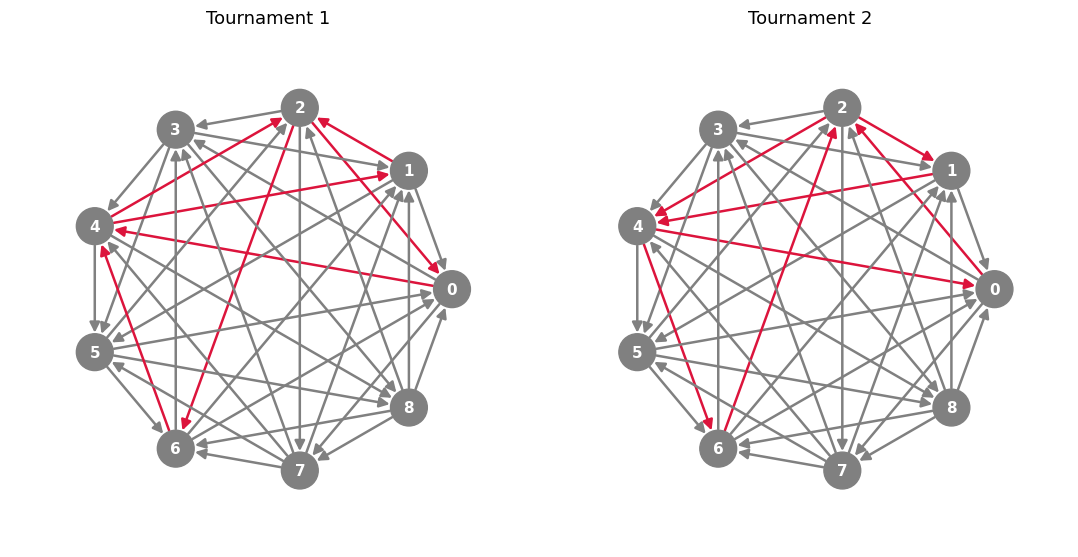

Comparing k-cycle counts for differing k:

k=7: T1=394, T2=390
k=8: T1=377, T2=383
k=9: T1=190, T2=196
['001100101001000100110110011001101000', '011000100011000110010110011101101000']


In [ ]:
n = len(cospectral_groups_to_n9)
print("Number of cospectral groups: ", n)
compare_tournaments(cospectral_groups_to_n9[16]) # change the number in [] to any number between 0 and n
print(cospectral_groups_to_n9[16])